# Tarefa 1 — Espaço de Escala, Visualização e Análise de Descritores
**Atividade 3 · TECA2 20261 · Pontos de Interesse e seus Descritores**

Este notebook cobre os 4 itens da Tarefa 1:
1. Pirâmide Gaussiana e DoG (Diferença de Gaussianas)
2. Visualização rica de keypoints (SIFT e AKAZE) em 3 imagens
3. Análise do descritor SIFT de 128 dimensões
4. Efeito da escala na detecção SIFT

### Base teórica (resumo)
- **Espaço de escala**: um objeto aparece em tamanhos diferentes conforme a distância da câmera. Para detectar a mesma estrutura independentemente do tamanho, geramos uma família de versões progressivamente borradas da imagem com filtro Gaussiano. Borrar com σ maior equivale a "afastar a câmera": detalhes finos somem, estruturas grandes permanecem.
- **Pirâmide Gaussiana**: organiza isso em *oitavas* (a imagem reduzida à metade) e *escalas* (níveis de borramento crescente dentro de cada oitava). Reduzir a imagem a cada oitava economiza computação.
- **DoG ≈ LoG**: o detector ideal de "blobs" seria o Laplaciano do Gaussiano (LoG), mas é caro. Lowe mostrou que a diferença entre duas imagens borradas com σ vizinhos aproxima o LoG: `DoG = G(kσ) − G(σ) ≈ (k−1)σ²·∇²G`. Os keypoints SIFT são extremos locais nessa pilha DoG (comparando cada pixel com 8 vizinhos no nível + 9+9 nos níveis vizinhos).
- **Descritor de 128 dim**: janela 16×16 ao redor do keypoint (na escala e orientação detectadas) → 4×4 sub-regiões → histograma de 8 direções em cada → 4×4×8 = **128 valores**.

> Referências: Corke (2023) Cap. 12, Seção 12.3.2 · Gonzalez & Woods (2018) Cap. 9, Seções 9.1–9.2 · Lowe (2004).

In [1]:
# Setup
import cv2
import numpy as np
import matplotlib.pyplot as plt

print('OpenCV:', cv2.__version__)
print('SIFT disponível:', hasattr(cv2, 'SIFT_create'))
print('AKAZE disponível:', hasattr(cv2, 'AKAZE_create'))

# Ajuste os caminhos conforme onde estão suas imagens.

PATH_PREDIO   = 'image/building2-2.png'
PATH_MONALISA = 'image/monalisa.png'
PATH_FIG0438  = 'image/Fig0438_a__bld_600by600_.tif'

def load(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img, gray

OpenCV: 4.13.0
SIFT disponível: True
AKAZE disponível: True


## Item 1 — Pirâmide Gaussiana e DoG

Construímos manualmente a pirâmide: 3 oitavas, 5 escalas por oitava. A cada escala aplicamos um Gaussiano com σ crescente (σₛ = σ₀·kˢ). A cada oitava, subamostramos a imagem pela metade. Em seguida calculamos a DoG subtraindo escalas adjacentes.

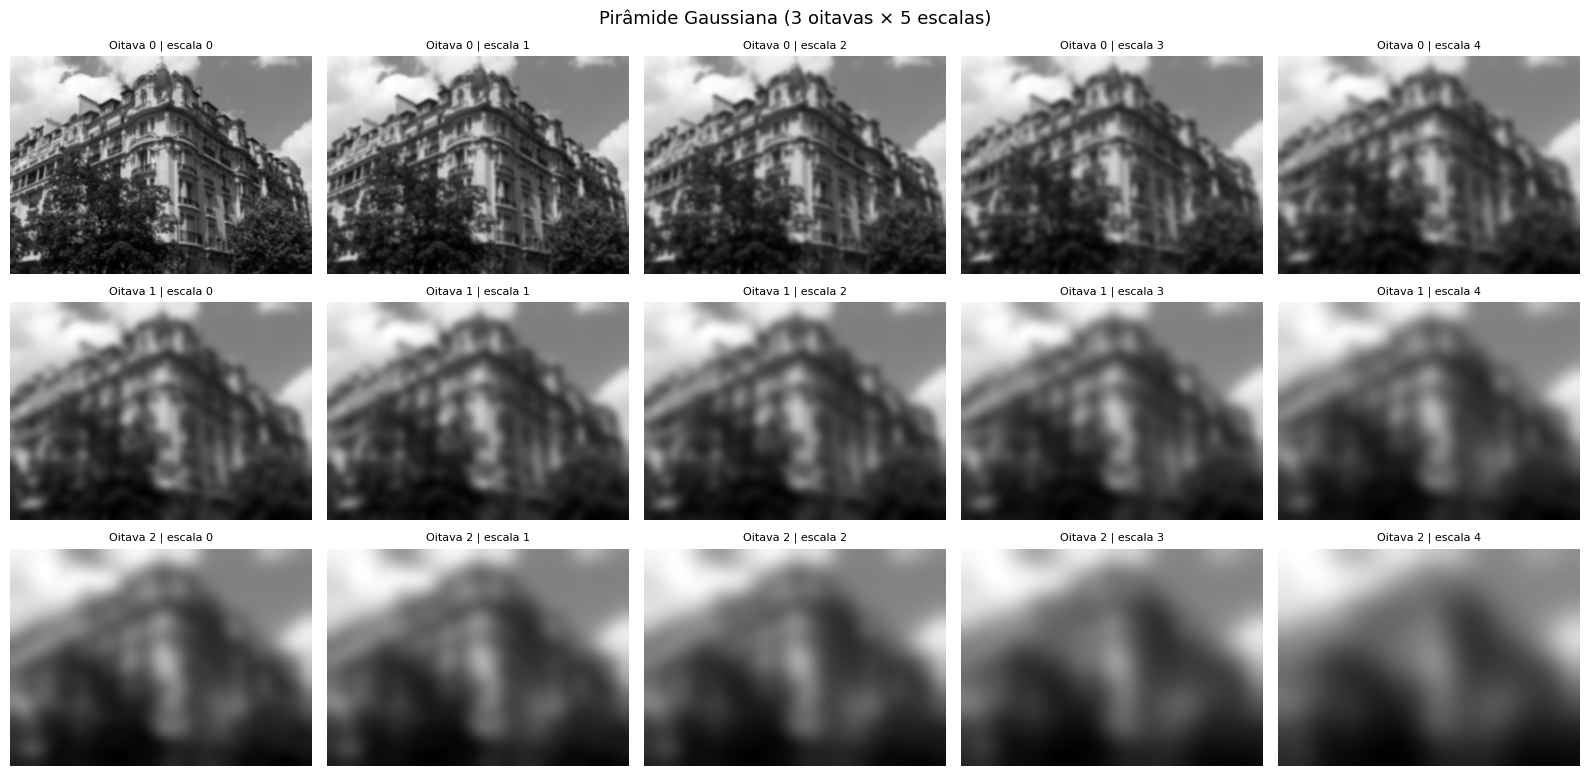

In [2]:
img_b, gray_b = load(PATH_PREDIO)

# Reduz para ~600px de largura (visualização leve)
scale = 600 / gray_b.shape[1]
gray_small = cv2.resize(gray_b, None, fx=scale, fy=scale)

def gaussian_pyramid(img, n_octaves=3, n_scales=5, sigma0=1.6):
    k = 2 ** (1 / (n_scales - 3)) if n_scales > 3 else np.sqrt(2)
    octaves = []
    base = img.astype(np.float32)
    for o in range(n_octaves):
        scales = [cv2.GaussianBlur(base, (0, 0), sigmaX=sigma0 * (k ** s))
                  for s in range(n_scales)]
        octaves.append(scales)
        base = cv2.resize(scales[-1], None, fx=0.5, fy=0.5,
                          interpolation=cv2.INTER_NEAREST)
    return octaves

pyr = gaussian_pyramid(gray_small, n_octaves=3, n_scales=5)

fig, axes = plt.subplots(3, 5, figsize=(16, 8))
for o in range(3):
    for s in range(5):
        axes[o, s].imshow(pyr[o][s], cmap='gray')
        axes[o, s].set_title(f'Oitava {o} | escala {s}', fontsize=8)
        axes[o, s].axis('off')
plt.suptitle('Pirâmide Gaussiana (3 oitavas × 5 escalas)', fontsize=13)
plt.tight_layout(); plt.show()

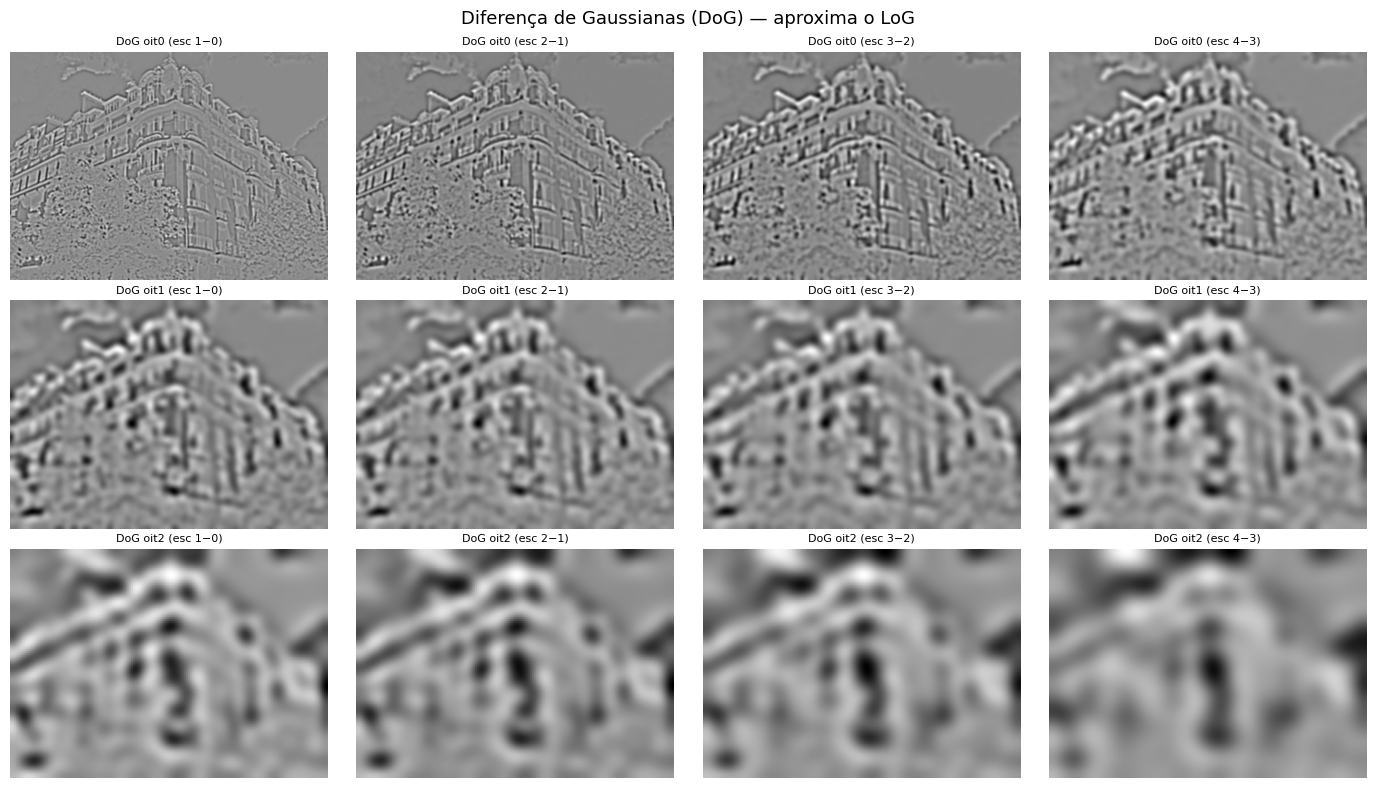

In [3]:
# DoG: diferença entre escalas adjacentes
fig, axes = plt.subplots(3, 4, figsize=(14, 8))
for o in range(3):
    for s in range(4):
        dog = pyr[o][s + 1] - pyr[o][s]
        axes[o, s].imshow(dog, cmap='gray')
        axes[o, s].set_title(f'DoG oit{o} (esc {s+1}−{s})', fontsize=8)
        axes[o, s].axis('off')
plt.suptitle('Diferença de Gaussianas (DoG) — aproxima o LoG', fontsize=13)
plt.tight_layout(); plt.show()

**Interpretação:** Na pirâmide, cada linha (oitava) parte de uma imagem com metade da resolução da anterior; dentro de cada linha o borramento aumenta da esquerda para a direita. Nas imagens DoG, as regiões claras/escuras realçam bordas e blobs em cada escala — é exatamente essa estrutura multiescala que o SIFT varre buscando extremos locais para definir keypoints. Estruturas finas (textura, janelas) respondem nas oitavas iniciais; estruturas grandes respondem nas oitavas finais.

## Item 2 — Visualização rica de keypoints (SIFT vs AKAZE)

Usamos 3 imagens com texturas variadas: fachada de prédio (cantos repetitivos + céu plano + árvores), Mona Lisa (textura pictórica) e a Fig0438 do Gonzalez. A flag `DRAW_RICH_KEYPOINTS` desenha círculos cujo **tamanho indica a escala** do keypoint e cujo **raio indica a orientação**.

Prédio (building2)       | SIFT:  9711 kp, desc (9711, 128) | AKAZE:  6368 kp, desc (6368, 61)
Mona Lisa                | SIFT:   815 kp, desc (815, 128) | AKAZE:   277 kp, desc (277, 61)
Fig0438 (Gonzalez)       | SIFT:   686 kp, desc (686, 128) | AKAZE:   264 kp, desc (264, 61)


[ WARN:0@4.275] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@4.275] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@4.275] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@4.275] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@4.275] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@4.275] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@4.275] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@4.275] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

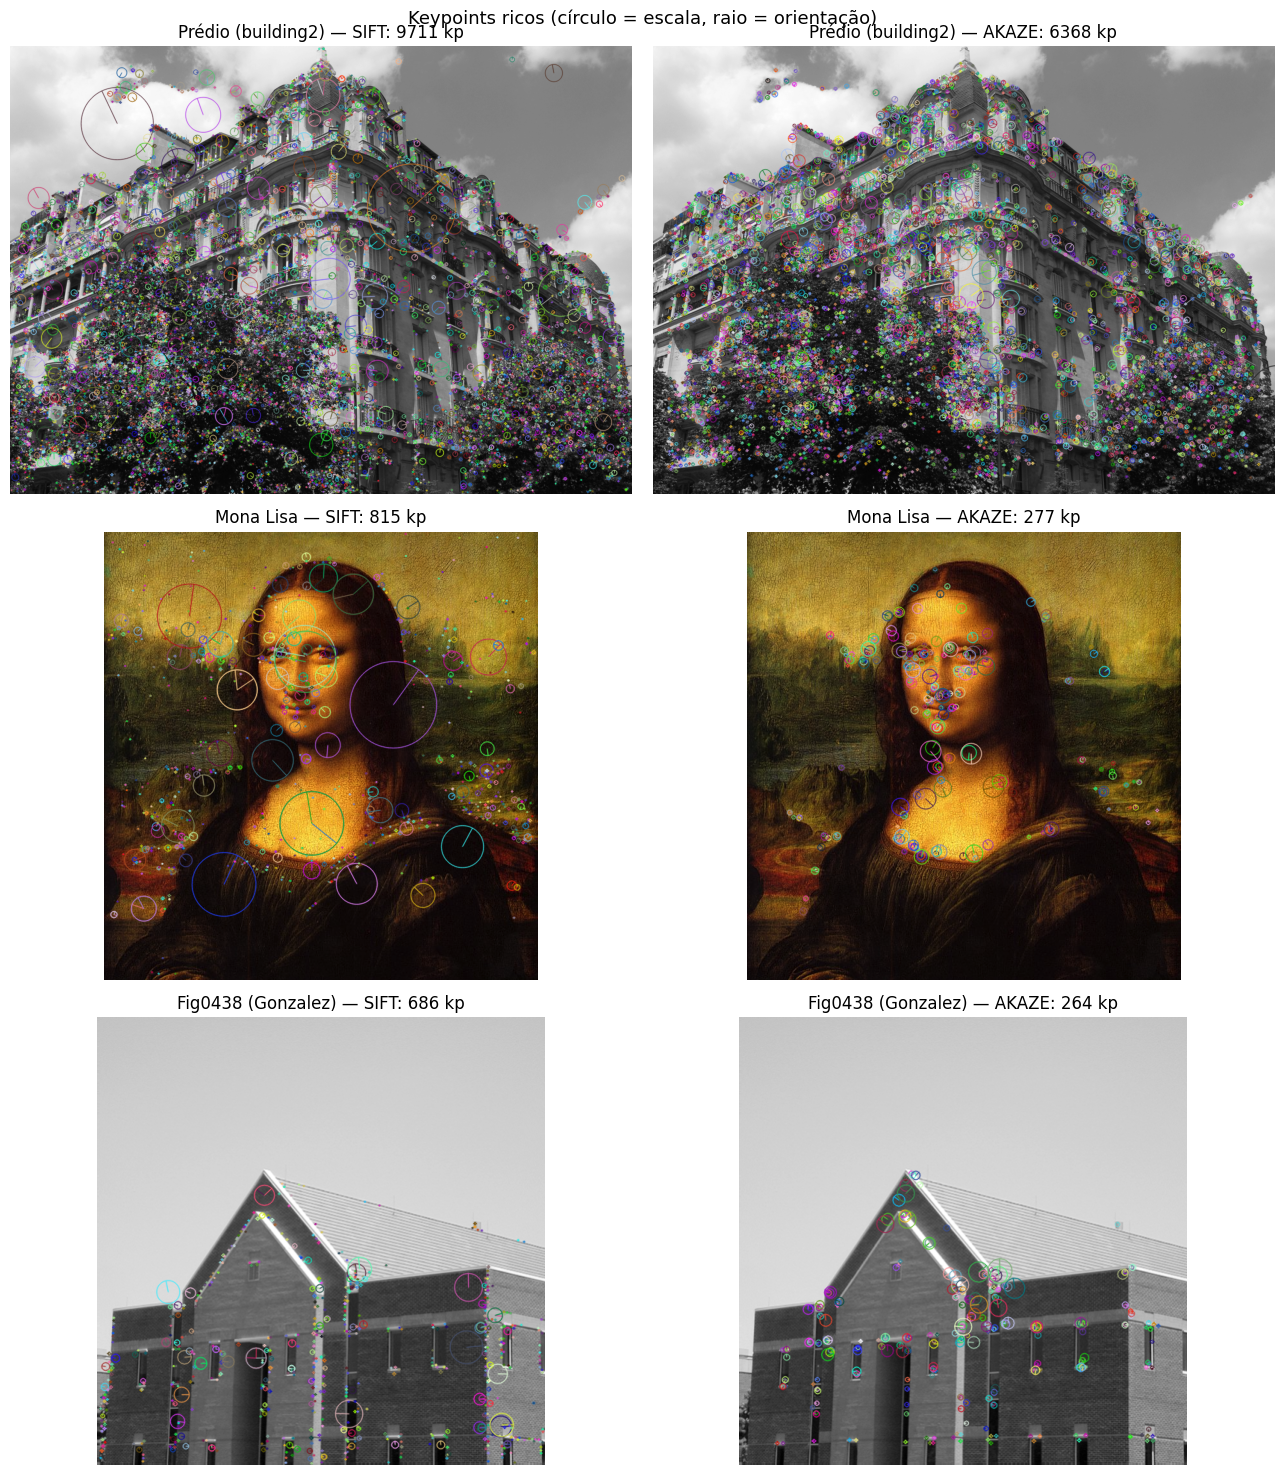

In [4]:
sift = cv2.SIFT_create()
akaze = cv2.AKAZE_create()
flag = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS

imgs = {
    'Prédio (building2)': PATH_PREDIO,
    'Mona Lisa': PATH_MONALISA,
    'Fig0438 (Gonzalez)': PATH_FIG0438,
}

fig, axes = plt.subplots(3, 2, figsize=(13, 15))
for i, (name, path) in enumerate(imgs.items()):
    img, gray = load(path)
    kp_s, d_s = sift.detectAndCompute(gray, None)
    kp_a, d_a = akaze.detectAndCompute(gray, None)
    print(f'{name:24s} | SIFT: {len(kp_s):5d} kp, desc {d_s.shape} '
          f'| AKAZE: {len(kp_a):5d} kp, desc {d_a.shape}')
    out_s = cv2.drawKeypoints(img, kp_s, None, flags=flag)
    out_a = cv2.drawKeypoints(img, kp_a, None, flags=flag)
    axes[i, 0].imshow(cv2.cvtColor(out_s, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(f'{name} — SIFT: {len(kp_s)} kp'); axes[i, 0].axis('off')
    axes[i, 1].imshow(cv2.cvtColor(out_a, cv2.COLOR_BGR2RGB))
    axes[i, 1].set_title(f'{name} — AKAZE: {len(kp_a)} kp'); axes[i, 1].axis('off')
plt.suptitle('Keypoints ricos (círculo = escala, raio = orientação)', fontsize=13)
plt.tight_layout(); plt.show()

**Observações esperadas:**
- O **céu** (região plana, sem gradiente) não recebe keypoints — confirma que pontos de interesse vivem em regiões com estrutura.
- A **fachada** e as **árvores** ficam densamente cobertas (muita textura e cantos).
- O **SIFT detecta substancialmente mais keypoints que o AKAZE** na mesma imagem (ex.: ~9600 vs ~6400 no prédio). O AKAZE é mais seletivo.
- O descritor SIFT tem **128 dimensões (float)**; o AKAZE tem **61 (binário)** — diferença que será central na Tarefa 2.

## Item 3 — Análise do descritor SIFT de 128 componentes

Selecionamos um keypoint de escala mediana e plotamos seus 128 valores. As linhas vermelhas separam as 16 sub-regiões (4×4), cada uma com 8 valores (uma por direção de gradiente).

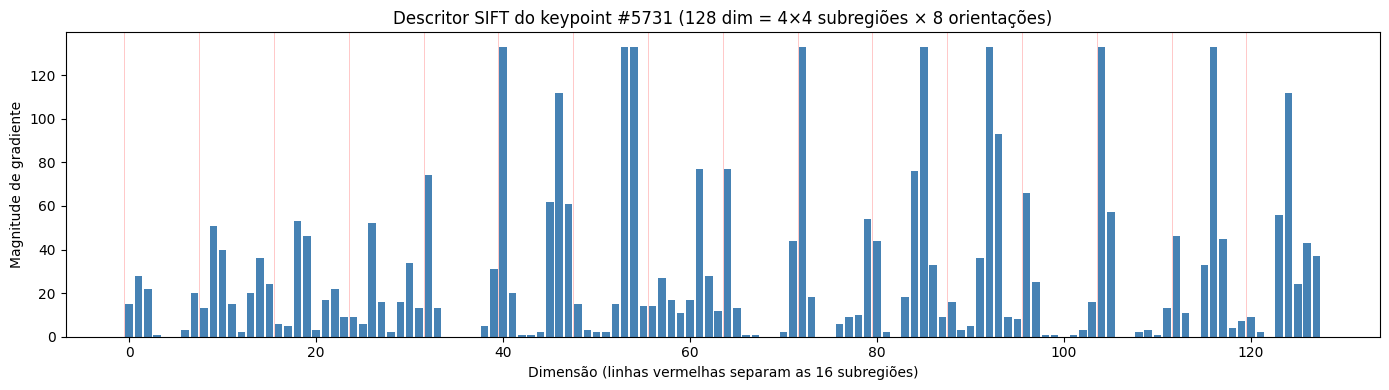

Escala do keypoint: 2.62
Orientação: 353.8°
Primeiros 8 valores (1ª subregião): [15. 28. 22.  1.  0.  0.  3. 20.]


In [5]:
img, gray = load(PATH_PREDIO)
kp_s, d_s = sift.detectAndCompute(gray, None)

# keypoint de escala mediana
idx = sorted(range(len(kp_s)), key=lambda i: kp_s[i].size)[len(kp_s) // 2]
desc = d_s[idx]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(128), desc, color='steelblue')
for b in range(0, 128, 8):
    ax.axvline(b - 0.5, color='red', alpha=0.25, lw=0.6)
ax.set_title(f'Descritor SIFT do keypoint #{idx} '
             f'(128 dim = 4×4 subregiões × 8 orientações)')
ax.set_xlabel('Dimensão (linhas vermelhas separam as 16 subregiões)')
ax.set_ylabel('Magnitude de gradiente')
plt.tight_layout(); plt.show()

print(f'Escala do keypoint: {kp_s[idx].size:.2f}')
print(f'Orientação: {kp_s[idx].angle:.1f}°')
print(f'Primeiros 8 valores (1ª subregião): {desc[:8]}')

**O que esses valores representam?** Cada grupo de 8 barras é o histograma de orientações de gradiente de uma das 16 sub-regiões da janela 16×16 ao redor do keypoint. A altura de cada barra é a soma das magnitudes de gradiente apontando naquela direção. Picos altos indicam uma direção de borda dominante naquela sub-região.

**Por que 128 dimensões?** Não é número arbitrário: 4×4 sub-regiões × 8 direções = 128. Esse arranjo equilibra poder de discriminação (suficiente para distinguir vizinhanças diferentes) com robustez (pequenas deformações não mudam o vetor drasticamente, pois cada sub-região agrega uma área). O vetor é normalizado para resistir a mudanças de iluminação.

## Item 4 — Efeito da escala (invariância do SIFT)

Redimensionamos a Mona Lisa para 100%, 50% e 25% e detectamos keypoints SIFT em cada versão.

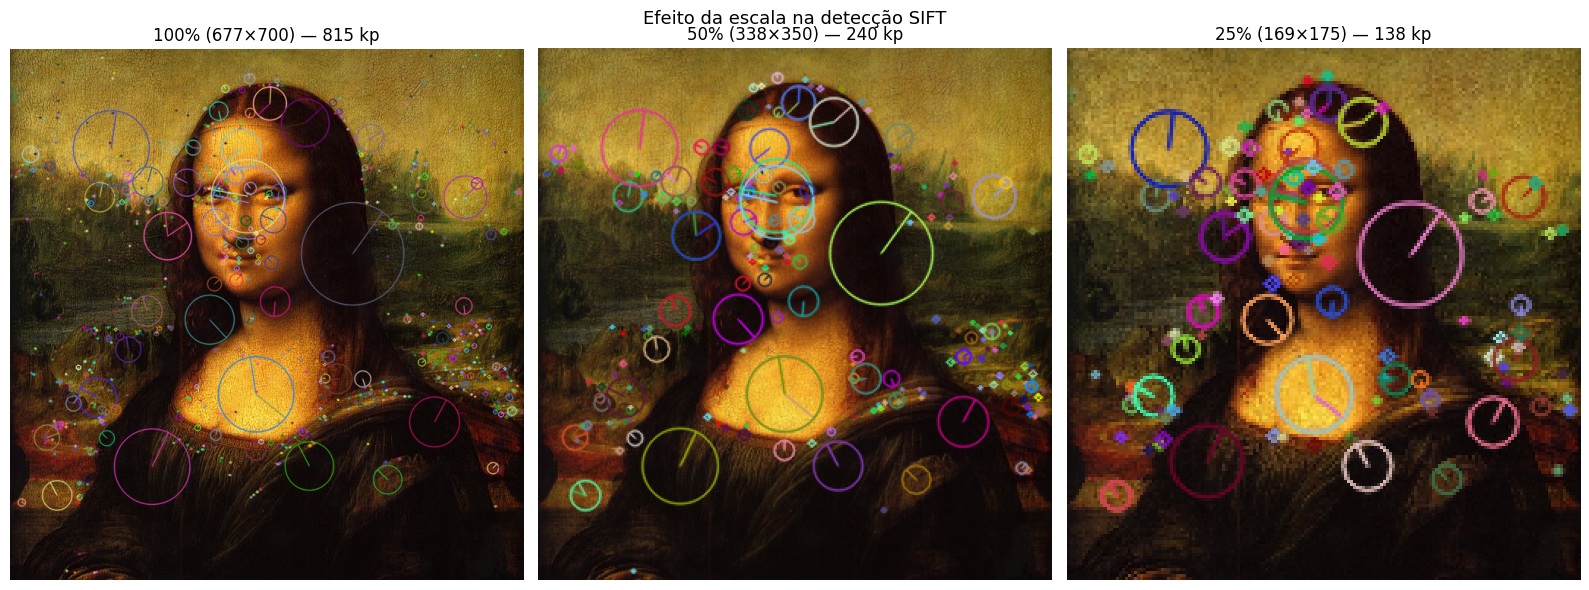

Keypoints por escala: {'100%': 815, '50%': 240, '25%': 138}


In [6]:
img, gray = load(PATH_MONALISA)
versions = {'100%': 1.0, '50%': 0.5, '25%': 0.25}

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
counts = {}
for i, (label, f) in enumerate(versions.items()):
    g = cv2.resize(gray, None, fx=f, fy=f) if f < 1 else gray
    c = cv2.resize(img, None, fx=f, fy=f) if f < 1 else img
    kp, d = sift.detectAndCompute(g, None)
    counts[label] = len(kp)
    out = cv2.drawKeypoints(c, kp, None, flags=flag)
    axes[i].imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f'{label} ({g.shape[1]}×{g.shape[0]}) — {len(kp)} kp')
    axes[i].axis('off')
plt.suptitle('Efeito da escala na detecção SIFT', fontsize=13)
plt.tight_layout(); plt.show()
print('Keypoints por escala:', counts)

**Discussão sobre invariância a escala:**
O número de keypoints cai conforme reduzimos a imagem (ex.: ~1066 → ~330 → ~142). Isso **não contradiz** a invariância a escala do SIFT — pelo contrário, ilustra seus limites. O SIFT é invariante a escala no sentido de que *um mesmo ponto detectado numa escala consegue ser casado com o mesmo ponto em outra escala*, porque o descritor é calculado numa janela proporcional à escala detectada.

Porém, quando a imagem é fisicamente reduzida, **detalhes finos deixam de existir nos pixels** (a subamostragem os elimina). Esses keypoints de alta frequência somem, sobrando apenas os de estruturas maiores, que persistem nas três versões. Ou seja: a invariância garante que os pontos *que sobrevivem* serão reconhecíveis entre escalas — não que todos os pontos sobreviverão à perda de resolução.

## Conclusão da Tarefa 1
- Construímos a pirâmide Gaussiana e a DoG, visualizando a estrutura multiescala que fundamenta a detecção SIFT.
- Comparamos SIFT (mais keypoints, descritor 128-float) e AKAZE (mais seletivo, descritor 61-binário) em três texturas; confirmamos que regiões planas (céu) não geram keypoints.
- Interpretamos o descritor de 128 dim como 16 histogramas de 8 orientações (4×4×8).
- Verificamos empiricamente que a invariância a escala do SIFT preserva os keypoints de estruturas grandes entre escalas, mas detalhes finos se perdem com a redução de resolução.